# Sentinel — End-to-End Pipeline

This notebook runs the project from the processed dataset through to the gate-on/off ablation, calling the
tested modules under `src/sentinel/`. It covers the data summary, the volatility circuit-breaker, the
LangGraph agent, and the trading simulation. The FinBERT sentiment model is trained separately in
`sentiment_finbert.ipynb` because it needs a GPU; its results are summarized here.

## Setup

Thread limits are set before importing torch to avoid a rare OpenMP deadlock between XGBoost and PyTorch.

In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import sys, pathlib
import torch
torch.set_num_threads(1)
import pandas as pd
import matplotlib.pyplot as plt

ROOT = pathlib.Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))
pd.set_option("display.width", 120)

In [2]:
from sentinel.utils.config import load_config
from sentinel.features.technical import FEATURE_COLUMNS
from sentinel.eda import plots

cfg = load_config(str(ROOT / "config" / "config.yaml"))
print("tickers:", cfg.data.tickers)
print("window:", cfg.data.start, "to", cfg.data.end)

tickers: ['SPY', 'QQQ', 'AAPL', 'MSFT', 'JPM', 'XOM', 'JNJ', 'NVDA', 'WMT', 'KO', 'AMZN', 'GOOGL', 'HD', 'PG', 'UNH', 'CVX']
window: 2010-01-01 to 2024-12-31


## 1. Dataset

The dataset is built once by `scripts/build_dataset.py` (acquire → clean → features → labels). Here we
load the processed table; rerun the build script if it is missing.

In [3]:
proc = ROOT / "data" / "processed" / "features_labeled.parquet"
if not proc.exists():
    raise FileNotFoundError("Run: python scripts/build_dataset.py --config config/config.yaml")

df = pd.read_parquet(proc)
labeled = df.dropna(subset=["label_highvol"]).copy()
labeled["label_highvol"] = labeled["label_highvol"].astype(int)
print(f"rows: {len(df):,} | labeled: {len(labeled):,} | tickers: {df['ticker'].nunique()}")
print(f"high-vol rate: {labeled['label_highvol'].mean():.1%} "
      f"({int(labeled['label_highvol'].sum()):,} positives)")
df[["date","ticker","close","ret_1","rvol_21","label_highvol"]].tail()

rows: 60,368 | labeled: 58,192 | tickers: 16
high-vol rate: 20.5% (11,955 positives)


,date,ticker,close,ret_1,rvol_21,label_highvol
60363,2024-12-23,XOM,106.300003,0.004053,0.008905,<NA>
60364,2024-12-24,XOM,106.400002,0.000940,0.008980,<NA>
60365,2024-12-26,XOM,106.489998,0.000845,0.008886,<NA>
60366,2024-12-27,XOM,106.480003,-0.000094,0.008582,<NA>
60367,2024-12-30,XOM,105.760002,-0.006785,0.008576,<NA>


## 2. Exploratory data analysis

The class is imbalanced by design, and the individual features correlate only weakly with the target, so
the task calls for a multivariate model rather than any single rule.

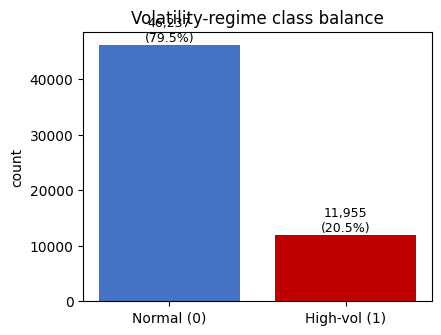

In [4]:
plots.plot_class_balance(labeled["label_highvol"]); plt.show()

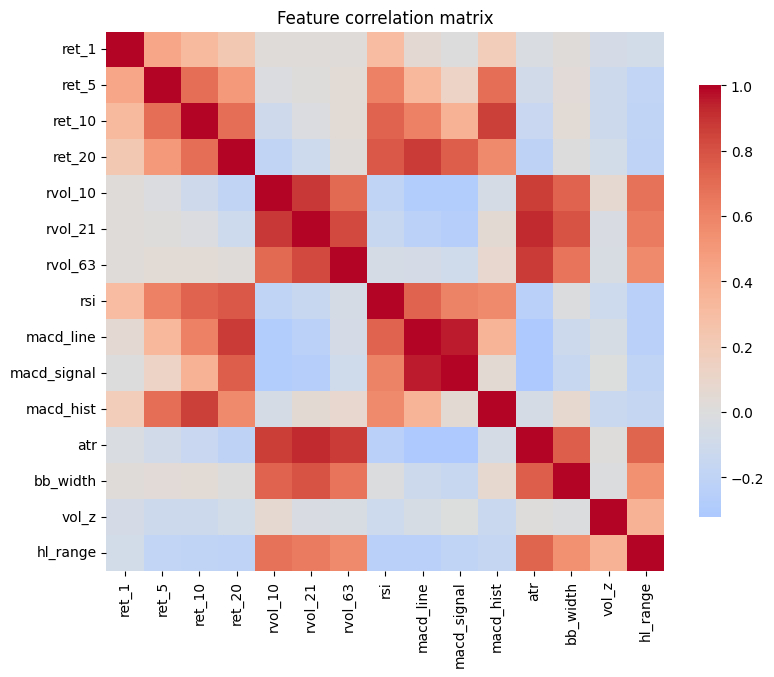

In [5]:
plots.plot_correlation(labeled, FEATURE_COLUMNS); plt.show()

In [6]:
adf = plots.adf_report(labeled, FEATURE_COLUMNS)
print("All features stationary (ADF p<0.05):", bool(adf["stationary_5pct"].all()))
adf.round(4)

All features stationary (ADF p<0.05): True


,feature,adf_stat,p_value,stationary_5pct
0,ret_1,-31.9613,0.0,True
1,ret_5,-32.1561,0.0,True
2,ret_10,-32.2210,0.0,True
3,ret_20,-31.5956,0.0,True
4,rvol_10,-16.0670,0.0,True
5,rvol_21,-16.8374,0.0,True
6,rvol_63,-15.3654,0.0,True
7,rsi,-26.9831,0.0,True
8,macd_line,-25.3744,0.0,True
9,macd_signal,-29.5803,0.0,True


## 3. Sentiment model (summary)

FinBERT is fine-tuned in `sentiment_finbert.ipynb` on a GPU. On the held-out test split it reached about
0.91 accuracy and 0.90 macro-F1, balanced across the negative, neutral, and positive classes, and it
degrades gracefully on out-of-domain tweets. Downstream it exposes a single directional score,
P(positive) minus P(negative), consumed by the agent's sentiment node.

## 4. Volatility circuit-breaker

The from-scratch neural network is compared against an XGBoost baseline using walk-forward retraining:
train on all history up to a year, predict the next year, then roll forward. This suits non-stationary
market data far better than a single fixed split.

In [7]:
from sentinel.models.volatility.walk_forward import walk_forward, mlp_fit_predict, xgb_fit_predict
from sentinel.models.volatility.evaluate import pick_threshold_max_f1, scores
from sklearn.metrics import average_precision_score, roc_auc_score

results = {}
for name, fp in [("MLP", mlp_fit_predict), ("XGBoost", xgb_fit_predict)]:
    oos = walk_forward(df, fp, start="2016-01-01")
    y, p = oos["label_highvol"].to_numpy(), oos["proba"].to_numpy()
    results[name] = oos
    print(f"{name:8} PR-AUC {average_precision_score(y,p):.3f} | ROC-AUC {roc_auc_score(y,p):.3f} "
          f"| base rate {y.mean():.3f}")

MLP      PR-AUC 0.444 | ROC-AUC 0.694 | base rate 0.209


XGBoost  PR-AUC 0.407 | ROC-AUC 0.680 | base rate 0.209


In [8]:
# Per-year PR-AUC for the neural network: sharp in turbulent years, dull in calm ones
oos = results["MLP"].copy()
oos["year"] = pd.to_datetime(oos["date"]).dt.year
by_year = oos.groupby("year").apply(
    lambda g: average_precision_score(g["label_highvol"], g["proba"]), include_groups=False)
by_year.round(2)

year
2016    0.36
2017    0.16
2018    0.64
2019    0.20
2020    0.70
2021    0.16
2022    0.52
2023    0.14
2024    0.32
dtype: float64

## 5. Agentic pipeline

The LangGraph agent walks each trading day. The volatility gate is a conditional edge: a normal day holds
the full book, a stressed day scales it down or halts. Below are one calm day and one crisis day.

In [9]:
from sentinel.agents.graph import run_day

for d in ["2016-05-26", "2020-03-16"]:
    st = run_day(pd.Timestamp(d))
    gross = round(sum(st["positions"].values()), 2)
    print(f"{d}: path={st['trace']}")
    print(f"   gross exposure = {gross} / {len(st['positions'])}")
    print(f"   {st['rationale']}\n")

2016-05-26: path=['market', 'sentiment', 'risk', 'portfolio', 'execution', 'rationale']
   gross exposure = 16.0 / 16
   2016-05-26: risk mode NORMAL (avg P(high-vol)=0.25 across 16 names). Held 16.00 gross; 0 names half-sized, 0 flat. Sentiment neutral (no live news feed in backtest).

2020-03-16: path=['market', 'sentiment', 'risk', 'portfolio', 'execution', 'rationale']
   gross exposure = 5.5 / 16
   2020-03-16: risk mode SCALED (avg P(high-vol)=0.66 across 16 names). Held 5.50 gross; 11 names half-sized, 5 flat. Sentiment neutral (no live news feed in backtest).



## 6. Gate-on vs gate-off ablation

The headline test: run the same strategy with the volatility gate off and on, changing nothing else.

In [10]:
from sentinel.sim.backtest import build_positions, simulate

oos = results["MLP"]
rets = df.assign(ret=lambda x: x["ret_1"].pipe(lambda r: (r.pipe(__import__("numpy").expm1))))[["date","ticker","ret"]]

rows = []
for gate_on in [False, True]:
    pos = build_positions(oos, gate_on=gate_on)
    _, m = simulate(pos, rets)
    rows.append({"gate": "on" if gate_on else "off",
                 "total_return": f"{m['total_return']:.0%}",
                 "sharpe": round(m["sharpe"], 2),
                 "max_drawdown": f"{m['max_drawdown']:.0%}",
                 "avg_exposure": round(m["avg_exposure"], 2)})
pd.DataFrame(rows).set_index("gate")

,total_return,sharpe,max_drawdown,avg_exposure
gate,,,,
off,420%,1.11,-31%,1.00
on,381%,1.23,-22%,0.98


The gate reduces the worst drawdown and raises the Sharpe ratio while barely changing average
exposure, because it acts on only the riskiest trading days. This supports the hypothesis that a learned
volatility circuit-breaker protects capital during turbulent periods rather than by sitting out the
market.